# Quantitative analysis of coherence-induced imaging artefacts

This notebook contains the analysis used to quantify the suppression of coherence-induced imaging artefacts presented in the supplementary material accompanying the manuscript 

*<div align ="center"> Absorption imaging of quantum gases near surfaces using incoherent light. </div>*

The analysis compares images acquired at different degrees of spatial coherence using two complementary measures:

1. the Fourier power contained within the spatial-frequency range associated with the observed fringe structure; and
2. the band-limited RMS fringe contrast.

The workflow consists of image preprocessing, background normalisation, Tukey windowing, Fourier analysis, spatial-frequency calibration, integrated Fourier-power calculation, and RMS-contrast calculation.


## 1. Import required packages

Here we import the relavant packages for this analysis

In [ ]:
import os                                                                                           # locating, organising, and accessing the image files used in the analysis.
from pathlib import Path                                                                            # locating, organising, and accessing the image files used in the analysis.

import numpy as np                                                                                  # numerical array handling and mathematical operations.
import pandas as pd                                                                                 # organising calculated quantities and analysis results into structured datasets.
import scipy as sp                                                                                  # scientific computing and signal-processing routines.
import matplotlib.pyplot as plt                                                                     # Plotting and visualization package.
from matplotlib.ticker import AutoMinorLocator, MaxNLocator,LogLocator, NullFormatter               # ontrolling major, minor, linear, and logarithmic axis ticks for publication-quality figures.

from PIL import Image                                                                               # image file handling and manipulation.
from scipy.ndimage import gaussian_filter                                                           # generating the slowly varying background used to normalise each image.
from scipy.signal.windows import tukey                                                              # For generating a smoothly varying window function to reduce edge effects in the Fourier transform.


In [2]:
# This cell is for plot formatting

plt.rcParams.update({
    "font.family": "serif",
    "text.usetex": True,

    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,

    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,
})

TEXTWIDTH = 6.8

Found 6 image files in C:\Users\Poppy\Desktop\PhD\Papers\IncoherentImaging\ReviwersResponse\IncoherentImagingManuscript\RawImages


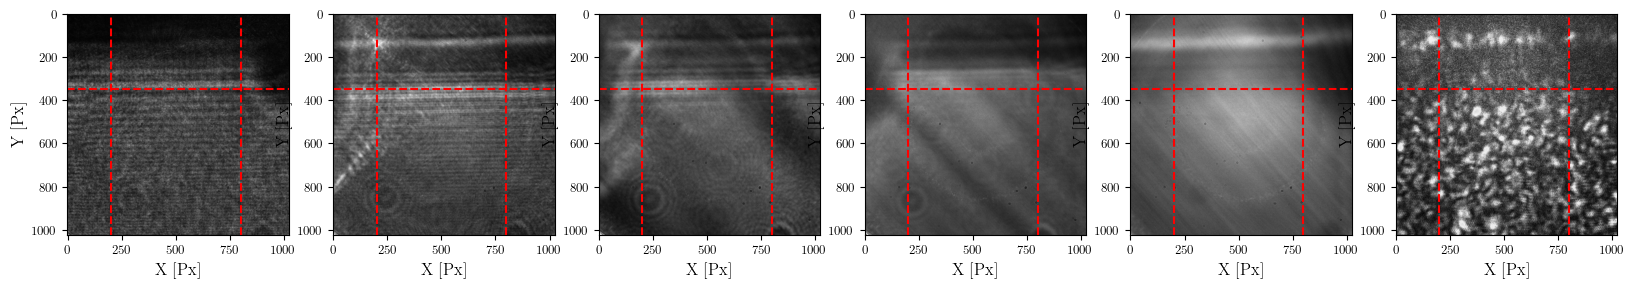

In [5]:
data_dir = Path("C:\\Users\\Poppy\\Desktop\\PhD\\Papers\\IncoherentImaging\\ReviwersResponse\\IncoherentImagingManuscript\\RawImages")        #Define data path

ImgFiles = sorted(data_dir.glob("*.png"))                                                           #Define image files to be analyzed
print(f"Found {len(ImgFiles)} image files in {data_dir}")                                           # Checks we have found all the files

Imgs = [Image.open(img_file) for img_file in ImgFiles]                                              # Open images and store them in a list

cropIndex = [200,800,350,1024]                                                                      # Define the crop region [xmin, xmax, ymin, ymax]

fig,ax = plt.subplots(1,len(Imgs),figsize=(20,50))                                                  # Create a figure and axes
for i in range(len(Imgs)):
    img = np.array(Imgs[i])                                                                         # Convert image to numpy array         
    ax[i].imshow(img, cmap="gray")                                                                  # plotting the images                                                          
    ax[i].set_xlabel('X [Px]')
    ax[i].set_ylabel('Y [Px]')
    ax[i].axhline(y=cropIndex[2], color='r', linestyle='--')                                        # Defining the top line for the crop region
    ax[i].axvline(x=cropIndex[0], color='r', linestyle='--')                                        # Defining the left line for the crop region
    ax[i].axvline(x=cropIndex[1], color='r', linestyle='--')
plt.show()                                                                                          # showing the figure

